<a href="https://colab.research.google.com/github/it-ces/PUBLIC-AI/blob/main/Probability/Simlab/poisson_panel_lgd_ead_monetary_loss(ai_page).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
# Iván Trujillo Abella
# ivantrujillo1229@gmail.com

In [60]:
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import numpy as np

In [61]:
url_train = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel_default_lgd_ead_modelling.csv"
url_test= "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel(test)_default_lgd_ead_modelling.csv"

In [62]:
panel_train = pd.read_csv(url_train)

panel_train['ead_at_default'] = np.where(panel_train['new_default'],
                                         panel_train['outstanding_balance'],0.0)
panel_train['loss_on_default'] = panel_train['ead_at_default'] * panel_train['lgd']
panel_train['loss_on_default'] = panel_train['loss_on_default']/1000000


panel_test = pd.read_csv(url_test)
panel_test['loss_on_default'] = panel_test['loss_on_default']/1000000

In [63]:
panel_train.columns

Index(['id_credit', 'cohort', 'delivery_date', 'execution_date', 'age_months',
       'term_months', 'original_amount', 'outstanding_balance',
       'days_past_due', 'default_state', 'new_default', 'at_risk', 'lgd',
       'ead_at_default', 'loss_on_default'],
      dtype='object')

In [64]:
historical_loss = panel_train.groupby('execution_date')[['loss_on_default']].sum()
display(historical_loss)
mean_loss = historical_loss['loss_on_default'].mean()

,loss_on_default
execution_date,
2023-01-31,3.316825
2023-02-28,28.232425
2023-03-31,22.353731
2023-04-30,50.597685
2023-05-31,51.231115
2023-06-30,51.747900
2023-07-31,35.120125
2023-08-31,37.689960
2023-09-30,84.532717


In [65]:
mean_loss # perdida promedio mensual

np.float64(53.14054230758949)

In [66]:
results = panel_test.groupby(by=['execution_date'])[['loss_on_default']].sum()
results

,loss_on_default
execution_date,
2028-01-31,55.347953
2028-02-29,88.444434
2028-03-31,75.875779
2028-04-30,57.689566
2028-05-31,55.839205
2028-06-30,65.872270
2028-07-31,66.618243
2028-08-31,56.991399
2028-09-30,46.402188


In [67]:
LAMBDA = panel_train.groupby(by=['execution_date'])['new_default'].sum().values.mean()

In [68]:
LAMBDA

np.float64(21.65)

In [69]:
severity = panel_train[panel_train['new_default']==1]['loss_on_default'].mean()
severity

np.float64(2.454528513052632)

In [70]:
LAMBDA  * severity

np.float64(53.140542307589484)

In [71]:
LAMBDA

np.float64(21.65)

In [72]:
poisson.ppf(0.99, LAMBDA) * severity

np.float64(80.99944093073687)

In [73]:
results['historical'] = mean_loss
results['expected_poisson'] = LAMBDA  * severity
results['sceneraio99_poisson'] = poisson.ppf(0.99, LAMBDA) * severity
results['sceneraio1_poisson'] = poisson.ppf(0.01, LAMBDA) * severity

In [74]:
results

,loss_on_default,historical,expected_poisson,sceneraio99_poisson,sceneraio1_poisson
execution_date,,,,,
2028-01-31,55.347953,53.140542,53.140542,80.999441,29.454342
2028-02-29,88.444434,53.140542,53.140542,80.999441,29.454342
2028-03-31,75.875779,53.140542,53.140542,80.999441,29.454342
2028-04-30,57.689566,53.140542,53.140542,80.999441,29.454342
2028-05-31,55.839205,53.140542,53.140542,80.999441,29.454342
2028-06-30,65.872270,53.140542,53.140542,80.999441,29.454342
2028-07-31,66.618243,53.140542,53.140542,80.999441,29.454342
2028-08-31,56.991399,53.140542,53.140542,80.999441,29.454342
2028-09-30,46.402188,53.140542,53.140542,80.999441,29.454342


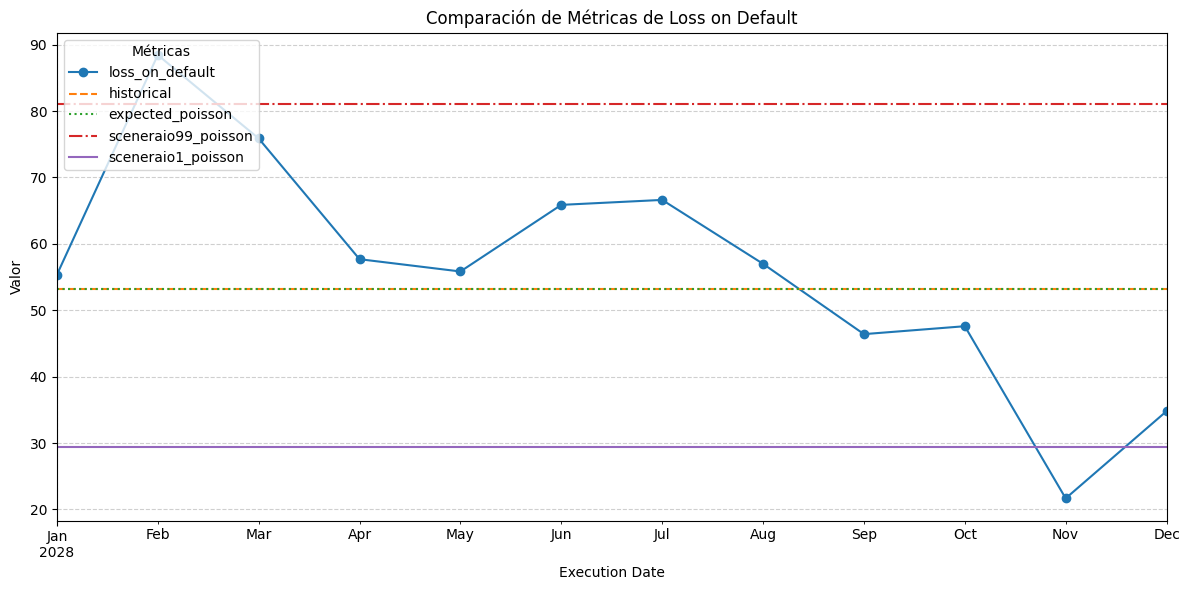

In [75]:
import matplotlib.pyplot as plt

# Asegurar que el índice sea tipo datetime para que el eje X se vea limpio
results.index = pd.to_datetime(results.index)

# Graficar las 4 columnas directamente desde Pandas
ax = results.plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.'], # Estilos de línea opcionales para mayor claridad
    title="Comparación de Métricas de Loss on Default"
)

# Personalizar etiquetas y leyenda
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [76]:
# Ajustemos... la exposición..
panel_train['new_default'].value_counts(normalize=True)

,proportion
new_default,
0,0.993908
1,0.006092


In [77]:
panel_train

,id_credit,cohort,delivery_date,execution_date,age_months,term_months,original_amount,outstanding_balance,days_past_due,default_state,new_default,at_risk,lgd,ead_at_default,loss_on_default
0,1,2023-01,2023-01-01,2023-01-31,0,14,9.411862e+06,9.411862e+06,0,0,0,1,0.474948,0.0,0.0
1,1,2023-01,2023-01-01,2023-02-28,1,14,9.411862e+06,8.739586e+06,0,0,0,1,0.474948,0.0,0.0
2,1,2023-01,2023-01-01,2023-03-31,2,14,9.411862e+06,8.067310e+06,0,0,0,1,0.474948,0.0,0.0
3,1,2023-01,2023-01-01,2023-04-30,3,14,9.411862e+06,7.395034e+06,0,0,0,1,0.474948,0.0,0.0
4,1,2023-01,2023-01-01,2023-05-31,4,14,9.411862e+06,6.722759e+06,0,0,0,1,0.474948,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213209,16268,2027-12,2027-12-31,2027-12-31,0,14,1.609272e+07,1.609272e+07,0,0,0,1,0.291342,0.0,0.0
213210,16269,2027-12,2027-12-31,2027-12-31,0,14,3.000000e+07,3.000000e+07,0,0,0,1,0.425676,0.0,0.0
213211,16270,2027-12,2027-12-31,2027-12-31,0,15,7.372265e+06,7.372265e+06,0,0,0,1,0.429045,0.0,0.0
213212,16271,2027-12,2027-12-31,2027-12-31,0,18,1.084091e+07,1.084091e+07,0,0,0,1,0.220547,0.0,0.0


In [78]:
N_t = panel_train.groupby('execution_date')['at_risk'].sum() # riesgo de su primer default

In [79]:
D_t = panel_train.groupby('execution_date')['new_default'].sum()

In [80]:
p_hat = (panel_train['new_default'].sum()/panel_train['at_risk'].sum())

In [81]:
p_hat

np.float64(0.0063466781320539005)

In [82]:
results_adj_size = (panel_test.groupby('execution_date')['at_risk'].sum().mul(p_hat).rename('lambda').reset_index())
results_adj_size['poisson_exposure_p05'] = poisson.ppf(0.05,results_adj_size['lambda'])
results_adj_size['poisson_exposure_p95'] = poisson.ppf(0.95,results_adj_size['lambda'])

In [83]:
results_adj_size['mean_loss']  = mean_loss

In [84]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss
0,2028-01-31,25.932527,18.0,35.0,53.140542
1,2028-02-29,27.157436,19.0,36.0,53.140542
2,2028-03-31,27.671517,19.0,37.0,53.140542
3,2028-04-30,27.963464,20.0,37.0,53.140542
4,2028-05-31,27.792104,19.0,37.0,53.140542
5,2028-06-30,27.252636,19.0,36.0,53.140542
6,2028-07-31,26.421221,18.0,35.0,53.140542
7,2028-08-31,25.450179,17.0,34.0,53.140542
8,2028-09-30,23.977750,16.0,32.0,53.140542
9,2028-10-31,22.454547,15.0,31.0,53.140542


In [85]:
results_adj_size['scenario_95'] = results_adj_size['poisson_exposure_p95'] * severity
results_adj_size['scenario_5'] = results_adj_size['poisson_exposure_p05'] * severity
results_adj_size['poisson_loss'] = results_adj_size['lambda'] * severity
results_adj_size['loss_on_default'] = results['loss_on_default'].values

In [86]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


In [87]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


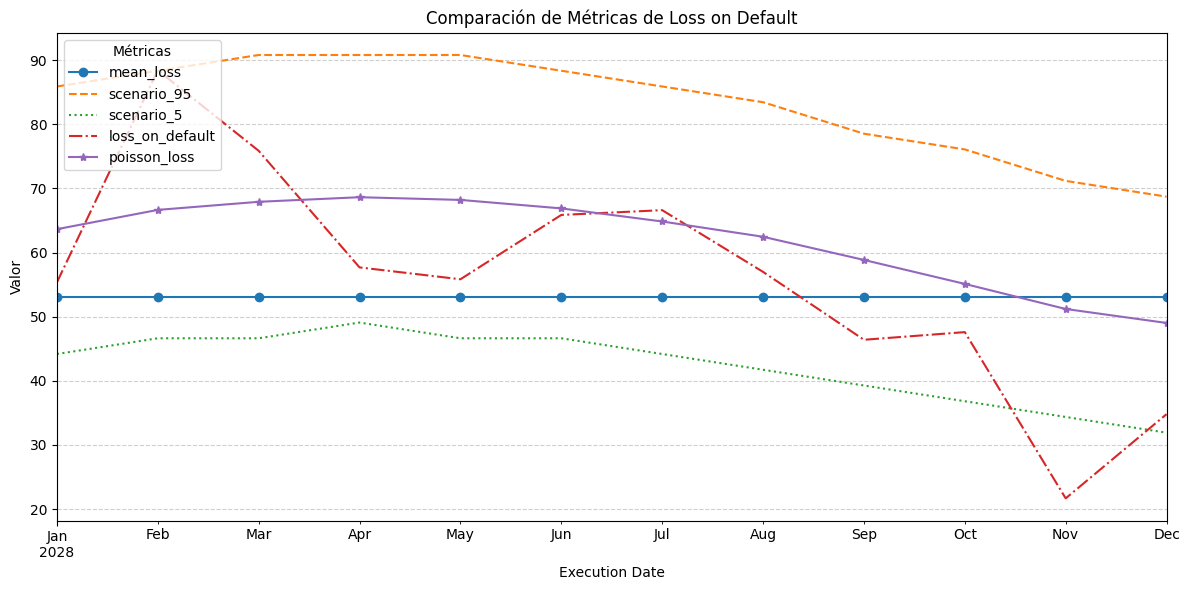

In [88]:
results_adj_size.index = pd.to_datetime(results_adj_size['execution_date'])
ax = results_adj_size[['mean_loss', 'scenario_95', 'scenario_5', 'loss_on_default', 'poisson_loss']].plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.','-*'],
    title="Comparación de Métricas de Loss on Default"
)
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [89]:
print((results_adj_size['loss_on_default'] - results_adj_size['mean_loss']).abs().sum()) # pérdida del histórico
print((results_adj_size['loss_on_default'] - results_adj_size['scenario_95']).abs().sum()) # pérdida de peor scenario
print((results_adj_size['loss_on_default'] - results_adj_size['poisson_loss']).abs().sum())# pérdida de poisson ajustada

159.64712190626614
326.0075125415811
133.3628645903873


In [90]:
(133.3628645903873  - 159.64712190626614)  / 159.64712190626614 * 100

-16.463971916331296

In [91]:
severity_data = panel_train.loc[
    panel_train["new_default"] == 1,
    "loss_on_default"
]

In [92]:
severity_data.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,loss_on_default
count,1299.000000
mean,2.454529
std,2.097975
min,0.082005
1%,0.147636
5%,0.286485
25%,0.946757
50%,1.886178
75%,3.299630
95%,6.671645


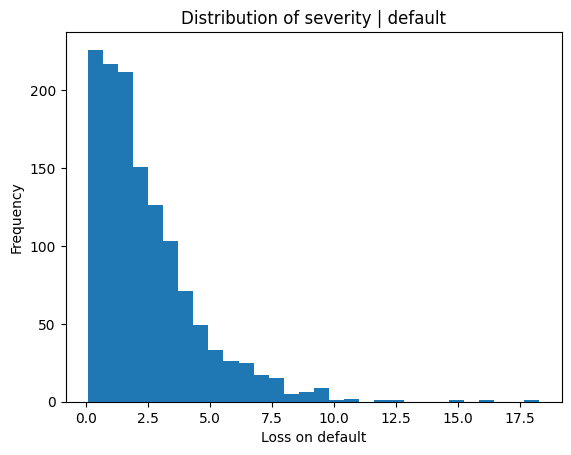

In [93]:
plt.hist(severity_data, bins=30)
plt.xlabel("Loss on default")
plt.ylabel("Frequency")
plt.title("Distribution of severity | default")
plt.show()

cada Default genera una pérdida aletoria $X$ por lo que la pérdida agregada es

\begin{equation}
S = \sum_{i=1}^{N} X_{i}
\end{equation}

# Boostrap empírico


In [94]:
losses_array = []
trials  = 100000
for _ in range(trials):
  n_defaults = np.random.poisson(LAMBDA)
  losses = np.random.choice(severity_data,size=n_defaults,replace=True)
  total_loss = losses.sum()
  losses_array.append(total_loss)
np.array(losses_array).mean()

np.float64(53.16000244772391)

In [95]:
np.quantile(losses_array, 0.99)

np.float64(92.50103715106611)

Meses de train: 59 | Test: 12 | Simulaciones por mes: 100,000

PREDICCIONES, BANDAS Y ERRORES — MILLONES


,actual_loss,lambda_regression,severity_dynamic,expected_dynamic,p05,p50,p95,absolute_error_dynamic,inside_band
month,,,,,,,,,
2028-01,55.348,26.462,2.350,62.198,37.892,61.108,89.893,6.850,True
2028-02,88.444,29.463,2.333,68.749,42.892,67.741,98.039,19.696,True
2028-03,75.876,29.182,2.277,66.450,41.319,65.368,95.160,9.426,True
2028-04,57.690,27.057,2.274,61.523,37.203,60.475,89.431,3.834,True
2028-05,55.839,27.426,2.275,62.396,37.725,61.397,90.500,6.557,True
2028-06,65.872,25.951,2.275,59.038,35.137,58.029,86.482,6.834,True
2028-07,66.618,27.015,2.270,61.313,36.788,60.214,89.244,5.305,True
2028-08,56.991,25.357,2.291,58.096,34.282,57.080,85.364,1.105,True
2028-09,46.402,23.970,2.271,54.438,31.953,53.537,80.416,8.036,True



COMPARACIÓN DE ERRORES — MENOR ES MEJOR


,MAE (millones),RMSE (millones),SAE (millones)
Modelo,,,
Promedio histórico,13.3039,17.2181,159.6471
"Poisson por exposición, severidad fija",11.1136,13.5410,133.3629
"Regresión Poisson, severidad fija",10.6173,13.2897,127.4078
"Regresión Poisson, severidad dinámica",8.9626,11.1925,107.5515


Reducción del MAE frente a Promedio histórico: 32.63%
Reducción del MAE frente a Poisson por exposición, severidad fija: 19.35%
Reducción del MAE frente a Regresión Poisson, severidad fija: 15.58%

Cobertura P05–P95: 91.67% (11/12 meses)
Anchura media de banda: 50.167 millones
Interval score90: 59.232 millones; menor es mejor
MAE defaults de la regresión: 3.274


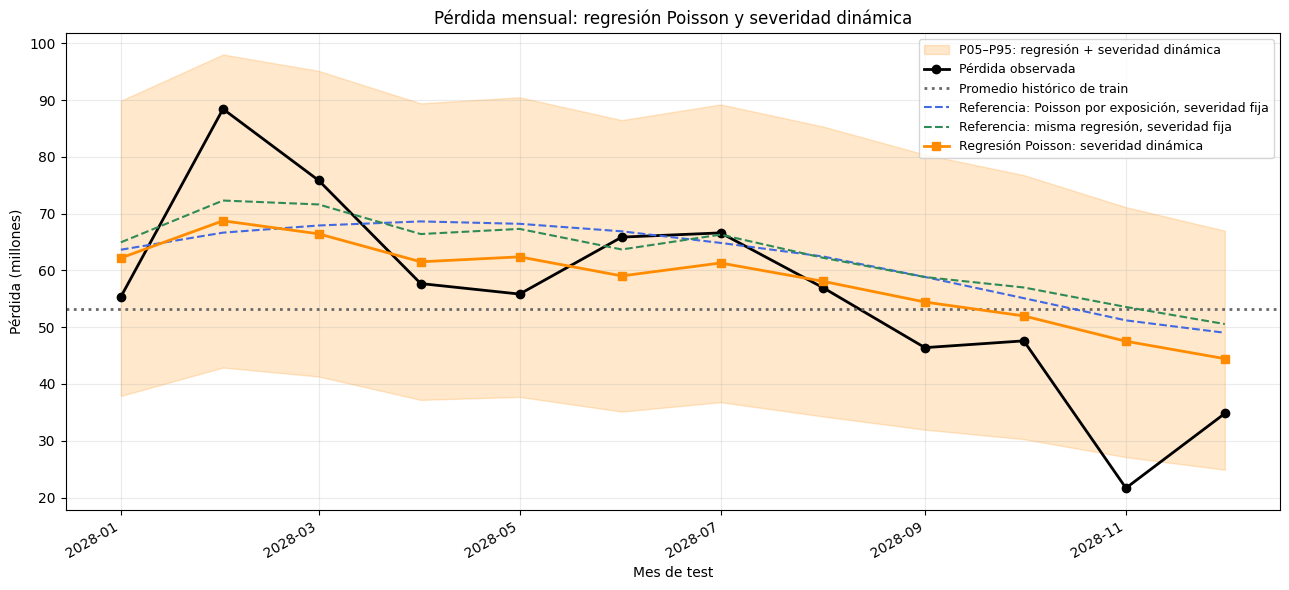


Supuestos: amortización lineal del ejercicio, LGD y composición disponibles al predecir. Se usan características del mes anterior para la frecuencia y se condiciona a la exposición del mes evaluado.
Las bandas simulan selección uniforme e independiente de severidades con reemplazo. No incluyen incertidumbre de parámetros.
La reducción del error de pronóstico no equivale a pérdidas reales evitadas.


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "statsmodels"
    ])
    import statsmodels.api as sm

B = 100_000
rng = np.random.default_rng(20261005)

# ==========================================================
# 1. DATOS MENSUALES Y PÉRDIDAS POTENCIALES POR CRÉDITO
# ==========================================================
def prepare_monthly(panel):
    data = panel.copy()
    data["month"] = (
        pd.to_datetime(data["execution_date"]).dt.to_period("M")
    )

    monthly = data.groupby("month").agg(
        defaults=("new_default", "sum"),
        at_risk=("at_risk", "sum"),
        actual_loss=("loss_on_default", "sum"),
    ).sort_index()

    risk = data.loc[data["at_risk"].eq(1)].copy()

    required = [
        "age_months", "term_months", "original_amount",
        "lgd", "days_past_due",
    ]

    if not np.isfinite(risk[required].to_numpy(dtype=float)).all():
        raise ValueError("Hay valores faltantes o no finitos.")

    if (risk["term_months"] <= 0).any() or (risk["age_months"] < 0).any():
        raise ValueError("Revisar plazos y antigüedades.")

    if (
        (risk["original_amount"] < 0).any()
        or not risk["lgd"].between(0, 1).all()
    ):
        raise ValueError("Revisar montos y LGD: debe estar entre 0 y 1.")

    risk["arrears"] = 100 * risk["days_past_due"].gt(0)
    risk["young"] = 100 * risk["age_months"].lt(3)

    # Amortización lineal del ejercicio.
    # No usamos ead_at_default observado para predecir.
    risk["projected_ead"] = risk["original_amount"] * (
        1 - risk["age_months"] / risk["term_months"]
    ).clip(lower=0)

    # LGD se supone disponible al predecir.
    risk["potential_loss"] = (
        risk["projected_ead"] * risk["lgd"] / 1_000_000
    )

    characteristics = risk.groupby("month").agg(
        mean_age=("age_months", "mean"),
        arrears_pct=("arrears", "mean"),
        young_pct=("young", "mean"),
        severity_dynamic=("potential_loss", "mean"),
    )

    return monthly.join(characteristics), risk


monthly_train, _ = prepare_monthly(panel_train)
monthly_test, risk_test = prepare_monthly(panel_test)

if monthly_train.index.max() >= monthly_test.index.min():
    raise ValueError("Train debe ser anterior a test.")

monthly = pd.concat([
    monthly_train.assign(split="train"),
    monthly_test.assign(split="test"),
]).sort_index()

calendar = pd.period_range(
    monthly.index.min(), monthly.index.max(), freq="M"
)

if not monthly.index.equals(calendar):
    raise ValueError("Hay meses faltantes o duplicados.")

# ==========================================================
# 2. PREDICTORES REZAGADOS UN MES
# ==========================================================
for column in ["mean_age", "arrears_pct", "young_pct"]:
    monthly[column + "_lag1"] = monthly[column].shift(1)

features = [
    "mean_age_lag1",
    "arrears_pct_lag1",
    "young_pct_lag1",
]

train = monthly.loc[monthly["split"].eq("train")].dropna(
    subset=features
).copy()

test = monthly.loc[monthly["split"].eq("test")].copy()

if (
    train.empty
    or test.empty
    or test[features + ["severity_dynamic"]].isna().any().any()
):
    raise ValueError("Faltan datos necesarios para entrenar o predecir.")

if (train["at_risk"] <= 0).any() or (test["at_risk"] <= 0).any():
    raise ValueError("Las exposiciones deben ser positivas.")

# ==========================================================
# 3. REGRESIÓN POISSON: ESTIMAR LAMBDA
#
# log(lambda_t) = log(at_risk_t) + beta0
#              + beta1 * edad_promedio_previa
#              + beta2 * porcentaje_mora_previo
#              + beta3 * porcentaje_jovenes_previo
# ==========================================================
X_train = sm.add_constant(train[features], has_constant="add")
X_test = sm.add_constant(test[features], has_constant="add")

model_poisson_dynamic = sm.GLM(
    train["defaults"],
    X_train,
    family=sm.families.Poisson(),
    offset=np.log(train["at_risk"]),
    missing="raise",
).fit()

if not model_poisson_dynamic.converged:
    raise RuntimeError("La regresión Poisson no convergió.")

results_dynamic = test[[
    "defaults", "at_risk", "actual_loss", "severity_dynamic"
]].copy()

results_dynamic["lambda_regression"] = model_poisson_dynamic.predict(
    X_test,
    offset=np.log(test["at_risk"]),
)

# Media analítica: no usamos la media simulada para evaluar el MAE.
results_dynamic["expected_dynamic"] = (
    results_dynamic["lambda_regression"]
    * results_dynamic["severity_dynamic"]
)

# ==========================================================
# 4. REFERENCIAS ESTIMADAS SOLO CON TRAIN
# ==========================================================
historical_mean = monthly_train["actual_loss"].mean()

severity_fixed = panel_train.loc[
    panel_train["new_default"].eq(1),
    "loss_on_default"
].mean()

if not np.isfinite(severity_fixed) or severity_fixed < 0:
    raise ValueError("No se pudo estimar la severidad de train.")

p_hat = (
    monthly_train["defaults"].sum()
    / monthly_train["at_risk"].sum()
)

results_dynamic["historical"] = historical_mean

results_dynamic["exposure_fixed"] = (
    results_dynamic["at_risk"] * p_hat * severity_fixed
)

results_dynamic["regression_fixed"] = (
    results_dynamic["lambda_regression"] * severity_fixed
)

# ==========================================================
# 5. BANDAS P05–P95
#
# N_t ~ Poisson(lambda de la regresión)
# S_t = suma de N_t pérdidas individuales
#
# Remuestreamos las pérdidas potenciales de la cartera del mes.
# ==========================================================
def simulate_losses(
    lambda_t, severities, n_sim, rng, batch_size=10_000
):
    if not np.isfinite(lambda_t) or lambda_t < 0:
        raise ValueError("Intensidad Poisson inválida.")

    totals = np.zeros(n_sim)

    for start in range(0, n_sim, batch_size):
        stop = min(start + batch_size, n_sim)
        counts = rng.poisson(lambda_t, size=stop - start)

        if counts.sum() > 0:
            sampled = rng.choice(
                severities,
                size=int(counts.sum()),
                replace=True,
            )

            totals[start:stop] = np.bincount(
                np.repeat(np.arange(len(counts)), counts),
                weights=sampled,
                minlength=len(counts),
            )

    return totals


bands = []

for month, row in results_dynamic.iterrows():
    severities = risk_test.loc[
        risk_test["month"].eq(month),
        "potential_loss"
    ].to_numpy()

    simulations = simulate_losses(
        row["lambda_regression"], severities, B, rng
    )

    p05, p50, p95 = np.quantile(
        simulations, [0.05, 0.50, 0.95]
    )

    bands.append({
        "month": month,
        "p05": p05,
        "p50": p50,
        "p95": p95,
        "simulated_mean": simulations.mean(),
    })

results_dynamic = results_dynamic.join(
    pd.DataFrame(bands).set_index("month")
)

results_dynamic["error_dynamic"] = (
    results_dynamic["actual_loss"]
    - results_dynamic["expected_dynamic"]
)

results_dynamic["absolute_error_dynamic"] = (
    results_dynamic["error_dynamic"].abs()
)

results_dynamic["inside_band"] = (
    results_dynamic["actual_loss"].between(
        results_dynamic["p05"], results_dynamic["p95"]
    )
)

# ==========================================================
# 6. MÉTRICAS DE ERROR
#
# MAE: error absoluto promedio mensual.
# RMSE: penaliza más los errores grandes.
# SAE: suma de errores absolutos en test.
# ==========================================================
actual = results_dynamic["actual_loss"]
metric_rows = []

for label, column in [
    ("Promedio histórico", "historical"),
    ("Poisson por exposición, severidad fija", "exposure_fixed"),
    ("Regresión Poisson, severidad fija", "regression_fixed"),
    ("Regresión Poisson, severidad dinámica", "expected_dynamic"),
]:
    error = actual - results_dynamic[column]

    metric_rows.append({
        "Modelo": label,
        "MAE (millones)": error.abs().mean(),
        "RMSE (millones)": np.sqrt(np.mean(error**2)),
        "SAE (millones)": error.abs().sum(),
    })

metrics_dynamic = pd.DataFrame(metric_rows).set_index("Modelo")

lower = results_dynamic["p05"]
upper = results_dynamic["p95"]

# Interval score al 90%: penaliza anchura y pérdidas fuera de banda.
interval_score = (upper - lower) + 20 * (
    np.maximum(lower - actual, 0)
    + np.maximum(actual - upper, 0)
)

print(
    f"Meses de train: {len(train)} | Test: {len(test)} "
    f"| Simulaciones por mes: {B:,}"
)

print("\nPREDICCIONES, BANDAS Y ERRORES — MILLONES")
display(results_dynamic[[
    "actual_loss",
    "lambda_regression",
    "severity_dynamic",
    "expected_dynamic",
    "p05",
    "p50",
    "p95",
    "absolute_error_dynamic",
    "inside_band",
]].round(3))

print("\nCOMPARACIÓN DE ERRORES — MENOR ES MEJOR")
display(metrics_dynamic.round(4))

new_mae = metrics_dynamic.iloc[-1]["MAE (millones)"]

for label in metrics_dynamic.index[:-1]:
    old_mae = metrics_dynamic.loc[label, "MAE (millones)"]

    if old_mae > 0:
        reduction = 100 * (1 - new_mae / old_mae)
        print(f"Reducción del MAE frente a {label}: {reduction:.2f}%")

inside_count = int(results_dynamic["inside_band"].sum())
coverage = 100 * results_dynamic["inside_band"].mean()

print(
    f"\nCobertura P05–P95: {coverage:.2f}% "
    f"({inside_count}/{len(test)} meses)"
)
print(f"Anchura media de banda: {(upper - lower).mean():.3f} millones")
print(
    f"Interval score90: {interval_score.mean():.3f} millones; "
    "menor es mejor"
)
print(
    "MAE defaults de la regresión: "
    f"{(results_dynamic['defaults'] - results_dynamic['lambda_regression']).abs().mean():.3f}"
)

# ==========================================================
# 7. GRÁFICA
# Naranja = modelo principal con severidad dinámica.
# Las otras líneas son referencias para comparar.
# ==========================================================
dates = results_dynamic.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(
    dates,
    lower.to_numpy(),
    upper.to_numpy(),
    color="darkorange",
    alpha=0.20,
    label="P05–P95: regresión + severidad dinámica",
)

ax.plot(
    dates, actual,
    "-o", color="black", linewidth=2,
    label="Pérdida observada",
)

ax.axhline(
    historical_mean,
    color="dimgray", linestyle=":", linewidth=2,
    label="Promedio histórico de train",
)

ax.plot(
    dates, results_dynamic["exposure_fixed"],
    "--", color="royalblue",
    label="Referencia: Poisson por exposición, severidad fija",
)

ax.plot(
    dates, results_dynamic["regression_fixed"],
    "--", color="seagreen",
    label="Referencia: misma regresión, severidad fija",
)

ax.plot(
    dates, results_dynamic["expected_dynamic"],
    "-s", color="darkorange", linewidth=2,
    label="Regresión Poisson: severidad dinámica",
)

ax.set(
    title="Pérdida mensual: regresión Poisson y severidad dinámica",
    xlabel="Mes de test",
    ylabel="Pérdida (millones)",
)

ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(
    "\nSupuestos: amortización lineal del ejercicio, LGD y composición "
    "disponibles al predecir. Se usan características del mes anterior "
    "para la frecuencia y se condiciona a la exposición del mes evaluado."
)
print(
    "Las bandas simulan selección uniforme e independiente de severidades "
    "con reemplazo. No incluyen incertidumbre de parámetros."
)
print(
    "La reducción del error de pronóstico no equivale "
    "a pérdidas reales evitadas."
)